# Day 3 模块 2：决策树——像一串 if

随机森林由很多决策树组成。先看懂一棵树，后面才好懂森林。


In [15]:
from pathlib import Path
import pandas as pd

candidate_paths = [
    Path('day3_cafe_sales.csv'),
    Path('day3') / 'day3_cafe_sales.csv',
    Path('教学课程') / 'day3' / 'day3_cafe_sales.csv',
]
for path in candidate_paths:
    if path.exists():
        csv_path = path
        break
else:
    raise FileNotFoundError('未找到 day3_cafe_sales.csv')

df = pd.read_csv(csv_path)
print(csv_path.resolve())
print('shape:', df.shape)
df.head()


D:\obi\熵学院\授课\机器学习-6小时\教学课程\day3\day3_cafe_sales.csv
shape: (200, 12)


,day,weather,weather_label,temp,is_weekend,promotion,quality,price,location,competitors,holiday,sales
0,1,1,多云,33.5,0,1,8.27,24.5,5.78,2,0,3249
1,2,2,阴,6.7,0,1,9.57,22.0,9.96,0,0,4700
2,3,0,晴,23.4,0,0,7.11,27.9,7.28,5,0,2071
3,4,2,阴,6.4,0,0,6.65,23.0,9.74,3,0,2370
4,5,0,晴,11.9,0,0,8.60,31.8,9.17,2,0,2847


## 1. 决策树在干什么

决策树可以先理解成：

> **自动学出来的**一串 if / else。

例如人可能会这样想：

```text
如果 weather_score 很高：
    如果 is_weekend == 1：
        营收可能更高
    否则：
        营收中等
否则：
    营收可能更低
```

重要一点：

- 这些 if **不是**老师事先写死的业务规则
- 是模型在历史数据里**自己搜索**出来的：“先问哪个特征、阈值大概卡在哪里”

人定的是：用哪些列当特征、树最多几层、任务是预测营收。  
**问什么、怎么切**，交给数据。


## 2. 树是怎么学习的（先建立感觉）

训练时，树不是一口气长出来的，而是**反复做同一件事：切一刀**。

```text
全部训练样本
    ↓ 找一刀最好的切分
左边一堆  |  右边一堆
    ↓          ↓
再各自找刀   再各自找刀
    ……
直到深度到了 / 不能再切
```

每一刀都长这样：

```text
某个特征  ?  某个阈值
例如：competitors <= 2
或：  promotion == 1
```

### 好刀的标准（白话）

模型会**试很多可能的切法**，比如：

- 用 `price` 在 25 切？
- 用 `price` 在 30 切？
- 用有没有促销切？
- 用竞争对手多/少切？

每试一种，就看切开后：

> 左边的营收是不是更整齐，右边是不是也更整齐。

- 切得好：一边多半偏低营收，一边多半偏高营收  
- 切得差：两边还是一样乱  

**谁让“乱”下降得最多，就选谁当这一层的问题。**

### “整齐 / 乱”怎么量？（回归：看平方误差）

今天预测的是营收**数字**，所以用「猜得偏不偏」来量：

```text
误差看的是：预测 − 实际，再平方
叶子上的预测：常见是该堆营收的平均值
```

- **切之前**：整堆人共用一个总平均去猜 → 有一个总误差 \(E_{前}\)
- **切之后**：左边用左平均、右边用右平均去猜 → 总误差

```text
E_后 = 左边每人(实际 − 左平均)²之和
     + 右边每人(实际 − 右平均)²之和
```

也可以理解成：**左右两边方差按人数加权平均**（人多的边话语权更大），和上面的 \(E_后\) 是一家人。

这一刀好不好，看它让误差降了多少：

```text
Gain = E_前 − E_后
```

- Gain 越大 → 切开后更整齐、更好猜 → **更好的刀**
- 算法在所有候选切法里，选 **Gain 最大** 的那一刀

人话对照：

| 人话 | 对应 |
| --- | --- |
| 更整齐 | 边内营收更接近边平均，\(E_后\) 更小 |
| 乱下降最多 | Gain 最大 |
| 叶子用平均 | 在「整叶只能猜一个数」时，平均让平方误差最小 |

> 网上分类教程常讲熵、信息增益、基尼——那是量**类别纯不纯**。  
> 我们预测金额，量的是 **平方误差 / 方差有没有降**。骨架一样（选 Gain 最大），尺子不同。

今天**不要求**手算 \(E_后\)，但要能说清：  
**选刀 = 让切开后用两边平均去猜时，总平方误差尽量小。**

### 小例子（假想 6 天，帮助想象）

| 天 | 促销 | 竞争对手 | 营收 |
| --- | --- | --- | --- |
| 1 | 有 | 少 | 3600 |
| 2 | 无 | 多 | 1800 |
| 3 | 有 | 少 | 3400 |
| 4 | 无 | 多 | 2000 |
| 5 | 有 | 多 | 2500 |
| 6 | 无 | 少 | 2800 |

模型可能先发现：按「竞争对手多/少」切开，两边营收差得更开、\(E_后\) 更小 → 第 1 刀选它。  
在某一支上再继续切，比如再问「有没有促销」。  

叶子上的预测数字，回归任务里常见做法是：

> 落到这个叶子的那些训练样本，营收的**平均值**。

### 学完之后怎么猜新的一天

新的一天只有特征、没有营收答案时：

```text
先问第 1 个条件 → 走左或走右
再问下一层 ……
最后落到某个叶子 → 输出叶子上的数字
```

**学习**发生在训练（`fit`）；  
**使用**发生在预测（`predict`）：只顺着已学好的问题往下走，不再改树结构。

### 和 `Y = KX + B` 对一下

| | 直线 `Y=KX+B` | 决策树 |
| --- | --- | --- |
| 学什么 | 学 K、B 两个数 | 学“问什么、阈值多少、叶子预测多少” |
| 怎么学 | 让预测和真实差变小 | 每一刀让平方误差（乱度）降得最多 |
| 学完长什么样 | 一条直线 | 一棵 if 树 |

同一句话：都是从数据里调整自己，让预测更接近真实营收。

### 三行板书（记牢）

```text
fit      = 学习（搜索最好的切分，长出 if 树）
predict  = 顺着 if 走路，给出营收猜测
max_depth = 最多问几层（太深容易“背题”）
选刀     = Gain = E_前 − E_后 尽量大（两边更整齐）
```


## 3. 准备 X 和 y


In [ ]:
# 准备特征和目标（沿用 Day 2 的思路）

# 先列出要当「线索」的列名（还不含天气文字列）
feature_cols = ['price', 'promotion', 'is_weekend', 'temp', 'quality', 'competitors', 'holiday', 'location']

# 把天气文字映射成 0~1 的数字分，模型才能直接用
# 晴最好，大雨最差
weather_score_map = {'晴': 1.0, '多云': 0.8, '阴': 0.6, '小雨': 0.4, '大雨': 0.3}

# copy 一份，避免后面改 df 时碰到奇怪的连锁警告
df = df.copy()

# 按 weather_label 查表，生成新列 weather_score
df['weather_score'] = df['weather_label'].map(weather_score_map)

# X：所有特征列拼在一起（数字线索）
X = df[feature_cols + ['weather_score']].copy()

# y：要预测的目标——营收 sales
y = df['sales'].copy()
y1 = df[['sales', 'weather_label']].copy()
# 这两个的区别是 y 只有 sales，一个没有columes，另一个

# 检查一下：特征有哪些、一共多少行
print('特征列:', list(X.columns))
print('样本数:', len(X))

# 看前几行，确认 X 里都是数字、没有文字天气
X.head()

print('目标列:', list(y1.columns))
print('样本数:', len(y1))

# 看前几行，确认 y1 里包含 sales 和 weather_label
y1.head()


特征列: ['price', 'promotion', 'is_weekend', 'temp', 'quality', 'competitors', 'holiday', 'location', 'weather_score']
样本数: 200
目标列: ['sales', 'weather_label']
样本数: 200


,sales,weather_label
0,3249,多云
1,4700,阴
2,2071,晴
3,2370,阴
4,2847,晴


## 4. 划分训练集和测试集

建模前，先把数据拆成两份（模块 1 讲过为什么）：

| 名字 | 干什么 | 今天大约多少 |
| --- | --- | --- |
| **训练集** | 给模型学习（`fit` 只用这份） | 80% |
| **测试集** | 学完后再考一次，看是不是真会 | 20% |

### 代码里两个参数

- **`test_size=0.2`**  
  大约 **20%** 的行拿去当测试，剩下约 80% 当训练。  
  写成 `0.2` 和写成 `test_size=40`（若总行数固定）不是一回事；这里用比例最常见。

- **`random_state=42`（随机种子）**  
  划分时要**随机**抽哪些行进测试集。  
  若不固定种子：你每次重跑，抽到的测试行可能不同 → R² 会抖。  
  写上 `42`：随机过程可复现，**全班、你自己多次运行，划分结果一样**。  
  **42 没有魔法**，换成 `0` 或 `1` 也可以，关键是「大家约定同一个数」。

人话：

> `test_size` 决定考卷占多少；`random_state` 决定「随机但可重复」。


In [17]:
# 从 sklearn 导入：按比例随机拆成训练/测试
from sklearn.model_selection import train_test_split

# 一次拆出四样东西（注意顺序不要记反）：
# X_train, X_test : 特征的训练/测试
# y_train, y_test : 营收的训练/测试
X_train, X_test, y_train, y_test = train_test_split(
    X,                 # 全部特征
    y,                 # 全部营收
    test_size=0.2,     # 约 20% 留给测试集
    random_state=42,   # 随机种子：固定后每次划分相同
)

# 看一下拆完各有多少行（200 行时大约 160 / 40）
print('训练集行数:', len(X_train))
print('测试集行数:', len(X_test))


训练集行数: 160
测试集行数: 40


## 5. 训练一棵浅决策树

下面这行 `fit`，就是在做上一节说的「试很多刀、选好刀、一层层长树」：

```python
tree.fit(X_train, y_train)
```

`max_depth=3` 表示：最多问 3 层就停。  
层数太深，容易把训练集背得很细，换到测试集不一定更好。今天先用浅树，方便看懂。

### 跑完格子会看到什么

```text
训练完成
训练集 R²: 0.xxx
测试集 R²: 0.xxx
```

- **训练完成**：`fit` 已经结束，树结构已经长好（if 已经定下来了）
- **`tree.score(...)`**：用某一份数据算一个总分，sklearn 对回归默认就是 **R²**
- **R² 先记直觉**（详细公式模块 6 再加深）：
  - 越接近 **1** → 预测越能跟上营收的高低波动
  - 接近 **0** → 几乎没比「每次都猜平均营收」强多少
  - 也可以小于 0（比瞎猜平均还差），今天少见就先知道有这回事

| 打印的是 | 用哪份数据算 | 含义 |
| --- | --- | --- |
| 训练集 R² | `X_train, y_train` | 模型在「自己练过的题」上表现如何 |
| 测试集 R² | `X_test, y_test` | 模型在「没练过的新题」上表现如何 |

**更该盯着看的是测试集 R²。**  
训练集分常常会高一点——题练过了更熟；如果训练很高、测试掉一截，就是过拟合的苗头（模块 1 的「背题」）。

浅树大约会出现类似这样的数（不必和屏幕上完全一样）：

```text
训练集 R² ≈ 0.7 左右
测试集 R² ≈ 0.5 左右
```

今天先会读这两个数；后面森林通常能把**测试集**再抬高一些。


In [33]:
# 导入「回归决策树」这个模型类
from sklearn.tree import DecisionTreeRegressor

# 先搭一棵浅树：最多 3 层；random_state 让树在同等数据下更可复现
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree2 = DecisionTreeRegressor(max_depth=4, random_state=42)
tree3 = DecisionTreeRegressor(max_depth=5, random_state=42)
tree4 = DecisionTreeRegressor(max_depth=6, random_state=42)
tree5 = DecisionTreeRegressor(max_depth=7, random_state=42)
tree6 = DecisionTreeRegressor(max_depth=16, random_state=42)

# 只用训练集学习（在这里真正「切刀、长树」）
tree.fit(X_train, y_train)
tree2.fit(X_train, y_train)
tree3.fit(X_train, y_train)
tree4.fit(X_train, y_train)
tree5.fit(X_train, y_train)
tree6.fit(X_train, y_train)


# fit 结束：树已经长好
print('训练完成')

# score：回归里默认算 R²（越接近 1 越好解释波动）
# 训练集：自己练过的题；测试集：没练过的新题（更该看这个）
print('tree 训练集 R²:', round(tree.score(X_train, y_train), 3))
print('tree 测试集 R²:', round(tree.score(X_test, y_test), 3))

print('tree2 训练集 R²:', round(tree2.score(X_train, y_train), 3))
print('tree2 测试集 R²:', round(tree2.score(X_test, y_test), 3))

print('tree3 训练集 R²:', round(tree3.score(X_train, y_train), 3))
print('tree3 测试集 R²:', round(tree3.score(X_test, y_test), 3))

print('tree4 训练集 R²:', round(tree4.score(X_train, y_train), 3))
print('tree4 测试集 R²:', round(tree4.score(X_test, y_test), 3))

print('tree5 训练集 R²:', round(tree5.score(X_train, y_train), 3))
print('tree5 测试集 R²:', round(tree5.score(X_test, y_test), 3))

print('tree6 训练集 R²:', round(tree6.score(X_train, y_train), 3))
print('tree6 测试集 R²:', round(tree6.score(X_test, y_test), 3))


训练完成
tree 训练集 R²: 0.718
tree 测试集 R²: 0.522
tree2 训练集 R²: 0.822
tree2 测试集 R²: 0.64
tree3 训练集 R²: 0.911
tree3 测试集 R²: 0.671
tree4 训练集 R²: 0.954
tree4 测试集 R²: 0.677
tree5 训练集 R²: 0.984
tree5 测试集 R²: 0.7
tree6 训练集 R²: 1.0
tree6 测试集 R²: 0.6


### 怎么读你刚打出来的两个数

对照自己的输出（数字可能略有出入）：

| 你看到的 | 可以怎么说 |
| --- | --- |
| `训练完成` | 树已经学完，可以 `predict` / 看结构了 |
| 训练集 R² 较高（如 0.7 左右） | 在练过的数据上，猜得还行 |
| 测试集 R² 低一些（如 0.5 左右） | 换新数据会掉一点分——浅树、单棵树都常见 |
| 训练明显高于测试 | 有一点「练题更熟、换卷变弱」的味道；先记下，后面用森林改善 |

注意：

- **R² 不是准确率百分比**，不要说成「52% 猜对了」
- **不是 0.99 才算成功**；今天浅树测试到 0.5 左右，已经能讲故事
- `score` 是一个总分；下一节看树长什么样，再下一节用 `predict` 看**每一天**猜多少


## 6. 打印树结构（文字）

`export_text` 把学到的问题打印出来。  
每一行 `特征 <= 某数`，就是训练时搜出来的一刀；最底下的 `value`，就是该叶子上的营收预测（常见是平均）。

先建立感觉即可：不必背每一行。下一节再**画**出来看。


In [19]:
from sklearn.tree import export_text

# 只打印前几层规则，建立感觉
print(export_text(tree, feature_names=list(X.columns), max_depth=3)[:1500])


|--- competitors <= 1.50
|   |--- promotion <= 0.50
|   |   |--- price <= 26.45
|   |   |   |--- value: [3671.08]
|   |   |--- price >  26.45
|   |   |   |--- value: [2913.27]
|   |--- promotion >  0.50
|   |   |--- price <= 24.05
|   |   |   |--- value: [5232.67]
|   |   |--- price >  24.05
|   |   |   |--- value: [3782.50]
|--- competitors >  1.50
|   |--- promotion <= 0.50
|   |   |--- holiday <= 0.50
|   |   |   |--- value: [2190.55]
|   |   |--- holiday >  0.50
|   |   |   |--- value: [3248.17]
|   |--- promotion >  0.50
|   |   |--- quality <= 8.13
|   |   |   |--- value: [2524.27]
|   |   |--- quality >  8.13
|   |   |   |--- value: [3227.73]



## 7. 画一画树结构（可视化）

文字规则有时不好扫，可以画成树形图。  
`max_depth=3` 时节点不多，刚好适合投屏。

> 图上每个框：问什么条件、这一堆大概多少样本、预测 value 是多少。  
> 特征名是英文列名，和 `export_text` 是同一棵树。


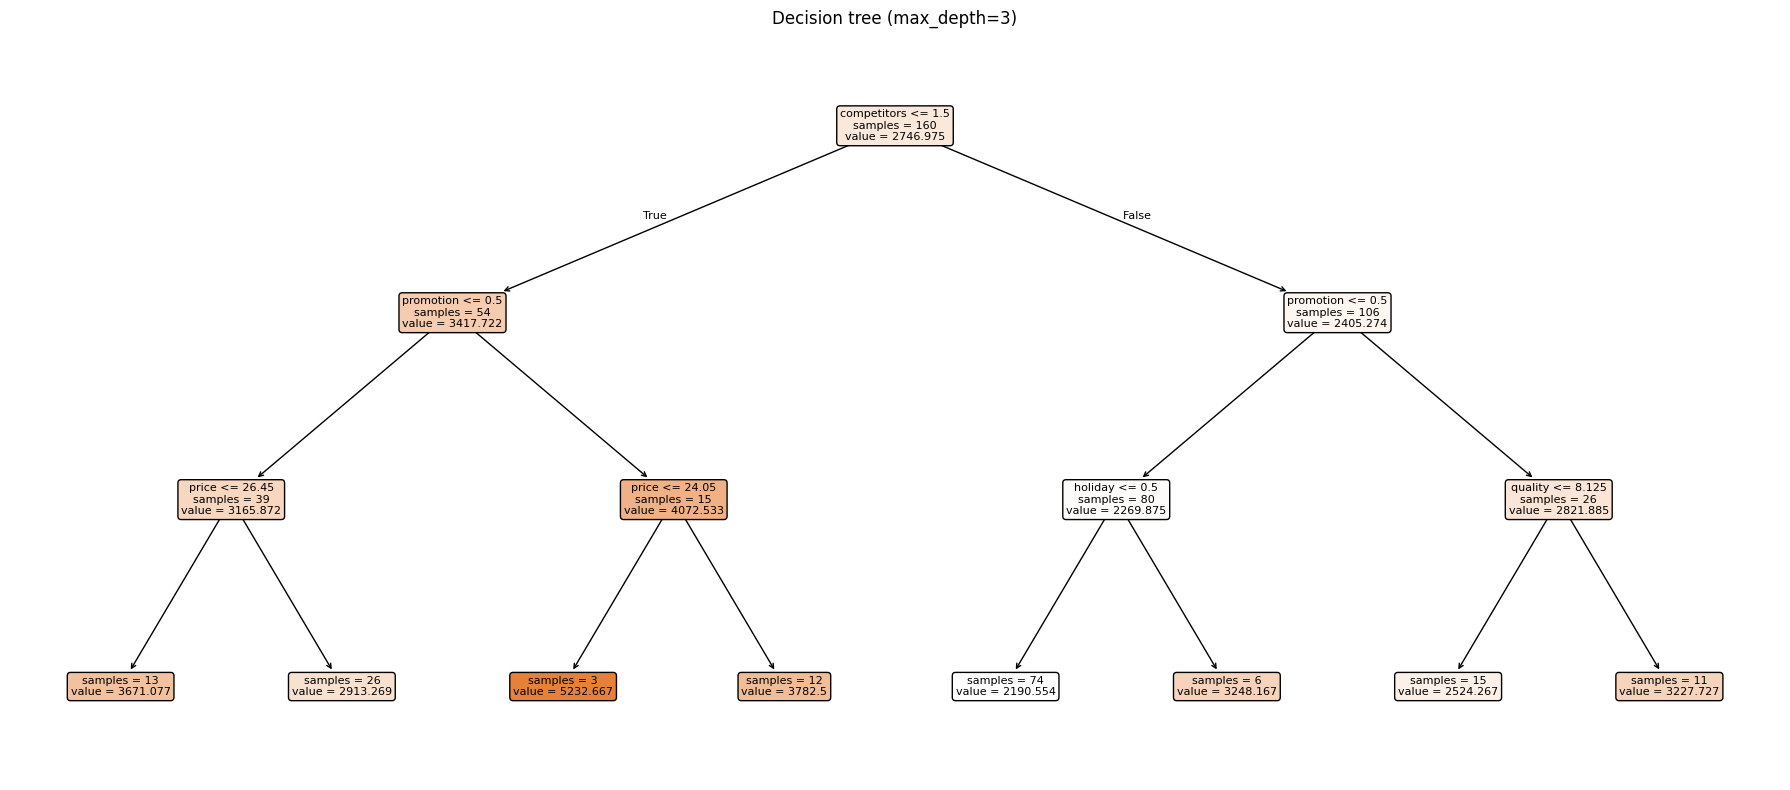

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=False,  # 回归树这里先不强调 impurity 数字
)
plt.title('Decision tree (max_depth=3)')
plt.tight_layout()
plt.show()


## 8. 用测试集做预测（对照表）

刚才的 **R²** 是整份测试集的一个总分。  
**`predict`** 则是：对每一行（每一天）单独给出一个营收猜测。

下面看测试集前几行：

| 列 | 含义 |
| --- | --- |
| 真实营收 | 测试集里真正的 `sales`（模型训练时没拿来 `fit`） |
| 树预测 | `tree.predict` 给出的数 |
| 偏差 | 预测 − 真实；有正有负都正常 |

有的天偏多、有的天偏少，所以才需要 R² 这种**总体**分数，不能只看某一行。


In [21]:
y_tree_pred = tree.predict(X_test)

compare = pd.DataFrame({
    '真实营收': y_test.to_numpy()[:10],
    '树预测': y_tree_pred[:10].round(1),
})
compare['偏差'] = (compare['树预测'] - compare['真实营收']).round(1)
print('测试集 R²（再确认一次）:', round(tree.score(X_test, y_test), 3))
compare


测试集 R²（再确认一次）: 0.522


,真实营收,树预测,偏差
0,2023,2190.6,167.6
1,5015,3782.5,-1232.5
2,2575,2913.3,338.3
3,3838,3782.5,-55.5
4,2396,2190.6,-205.4
5,2337,2190.6,-146.4
6,2131,2190.6,59.6
7,2397,2190.6,-206.4
8,3813,2913.3,-899.7
9,1893,2190.6,297.6


## 9. 决策树的局限（先记住结论）

- 一棵树有时会“背题”，换数据就不稳  
- 小改动数据，树结构可能大变  

所以后面会用很多棵树一起工作——这就是随机森林。  
（森林里每一棵树，都会在自己那份数据上做同一套「切刀学习」。）


## 10. 小练习

请试试：

1. 把 `max_depth` 改成 2 或 5，观察**训练 / 测试 R²**怎么变；哪一个更该当「成绩单」？  
2. 用自己的话写一句：决策树在做什么  
3. 口头回答：树的 if 是人写死的，还是从数据里搜出来的？“学”的时候在找什么？  
4. 口头回答：我们选刀时，\(E_后\) / Gain 大概在比什么？  
5. 看一眼 `plot_tree` 图：根节点在问哪个特征？和 `export_text` 是否对得上？  
6. 口头回答：R² 接近 1 和接近 0，各表示什么感觉？（不要说成「猜对百分之几」）


In [22]:
# 在这里写
